In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

In [5]:
df_final = pd.read_csv("dataset/enriched_dataset.csv", sep=";")

## Modèle Naïf 

Colonne datetime détectée : datetime

MODÈLES NAÏFS - PRÉDICTION AVEC SPLIT 80/20

Dataset total : 9266 points
Train : 7412 points (80%)
Test : 1854 points (20%)

Période d'entraînement : 2024-09-01 03:00:00+00:00 à 2025-08-13 16:00:00+00:00
Période de test : 2025-08-13 17:00:00+00:00 à 2025-10-29 23:00:00+00:00

ANALYSE POUR : DEBIT_HORAIRE

📊 Création des prédictions naïves...
✓ Modèles créés : 2
  - Lag 1 Semaine
  - Moyenne Heure Jour

RÉSULTATS - RMSE
            Modèle       RMSE  N échantillons
Moyenne Heure Jour 131.485606            1773
     Lag 1 Semaine 204.799849            1417

🏆 MEILLEUR MODÈLE : Moyenne Heure Jour
   RMSE : 131.49

📈 Génération des graphiques...


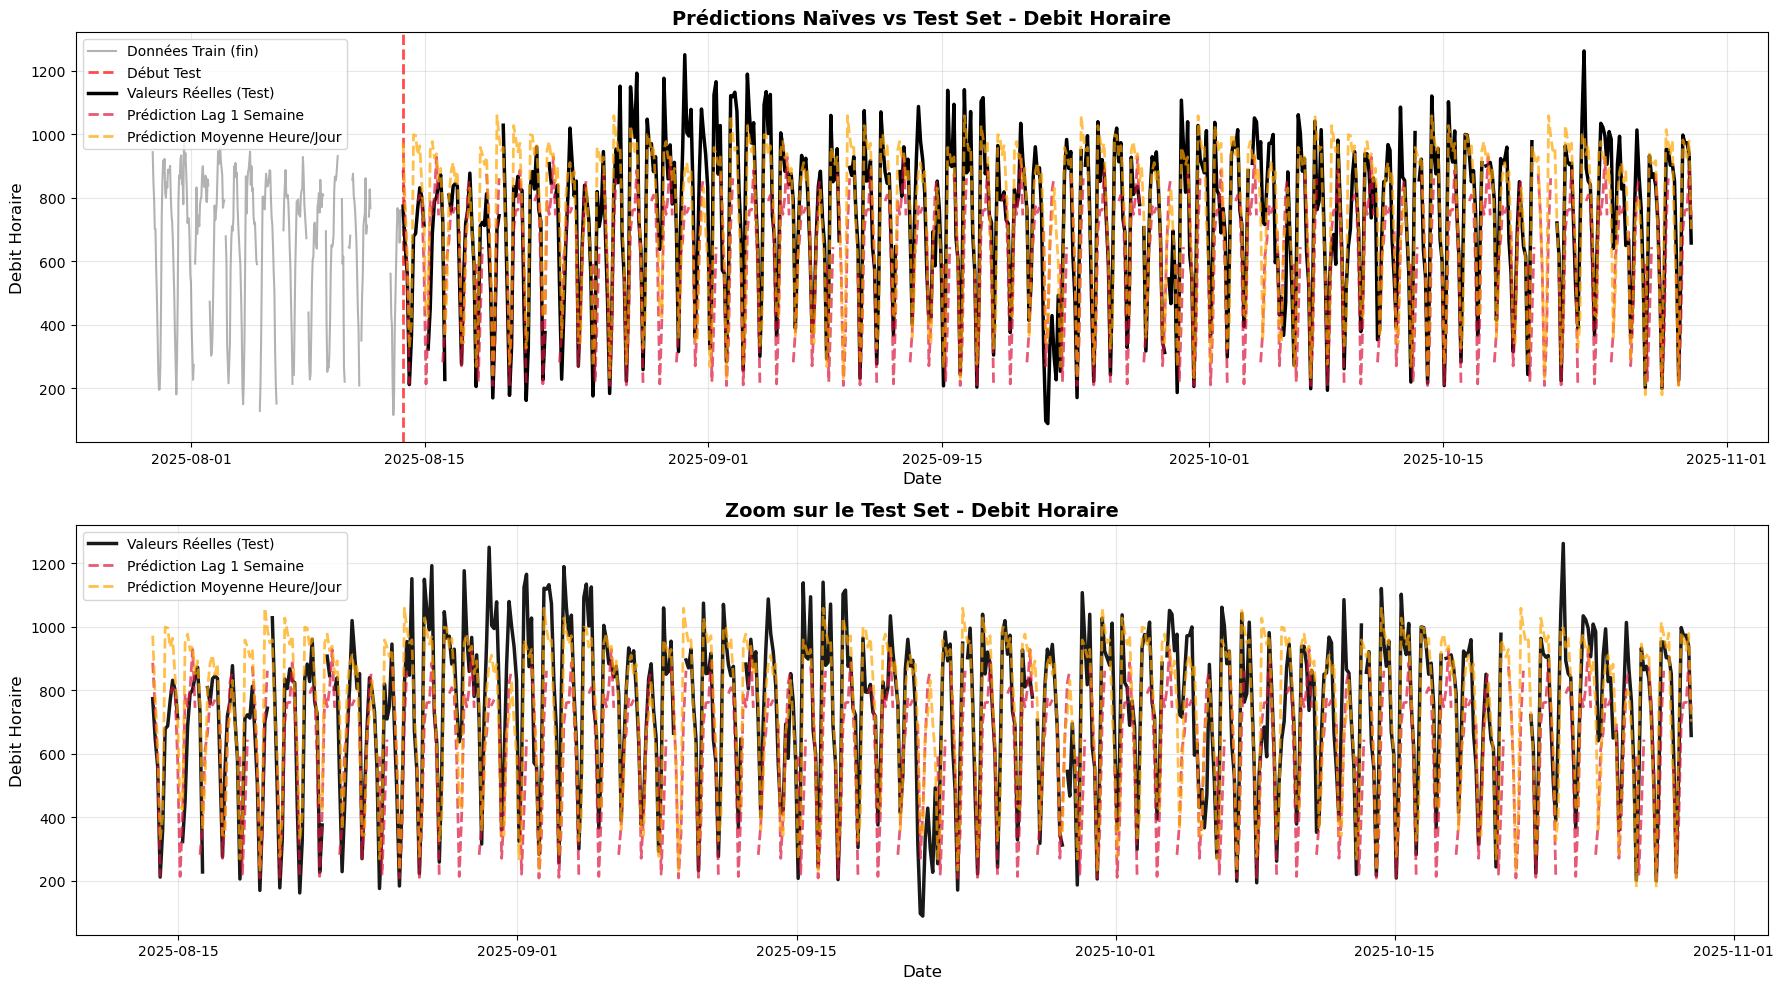

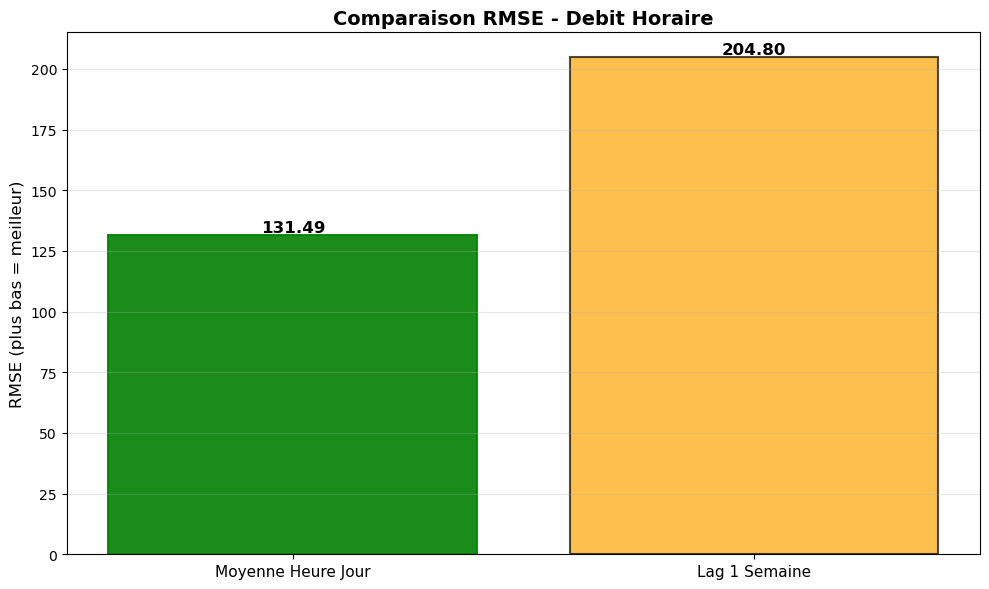


ANALYSE POUR : TAUX_OCCUPATION

📊 Création des prédictions naïves...
✓ Modèles créés : 2
  - Lag 1 Semaine
  - Moyenne Heure Jour

RÉSULTATS - RMSE
            Modèle     RMSE  N échantillons
Moyenne Heure Jour 6.572763            1773
     Lag 1 Semaine 8.250055            1417

🏆 MEILLEUR MODÈLE : Moyenne Heure Jour
   RMSE : 6.57

📈 Génération des graphiques...


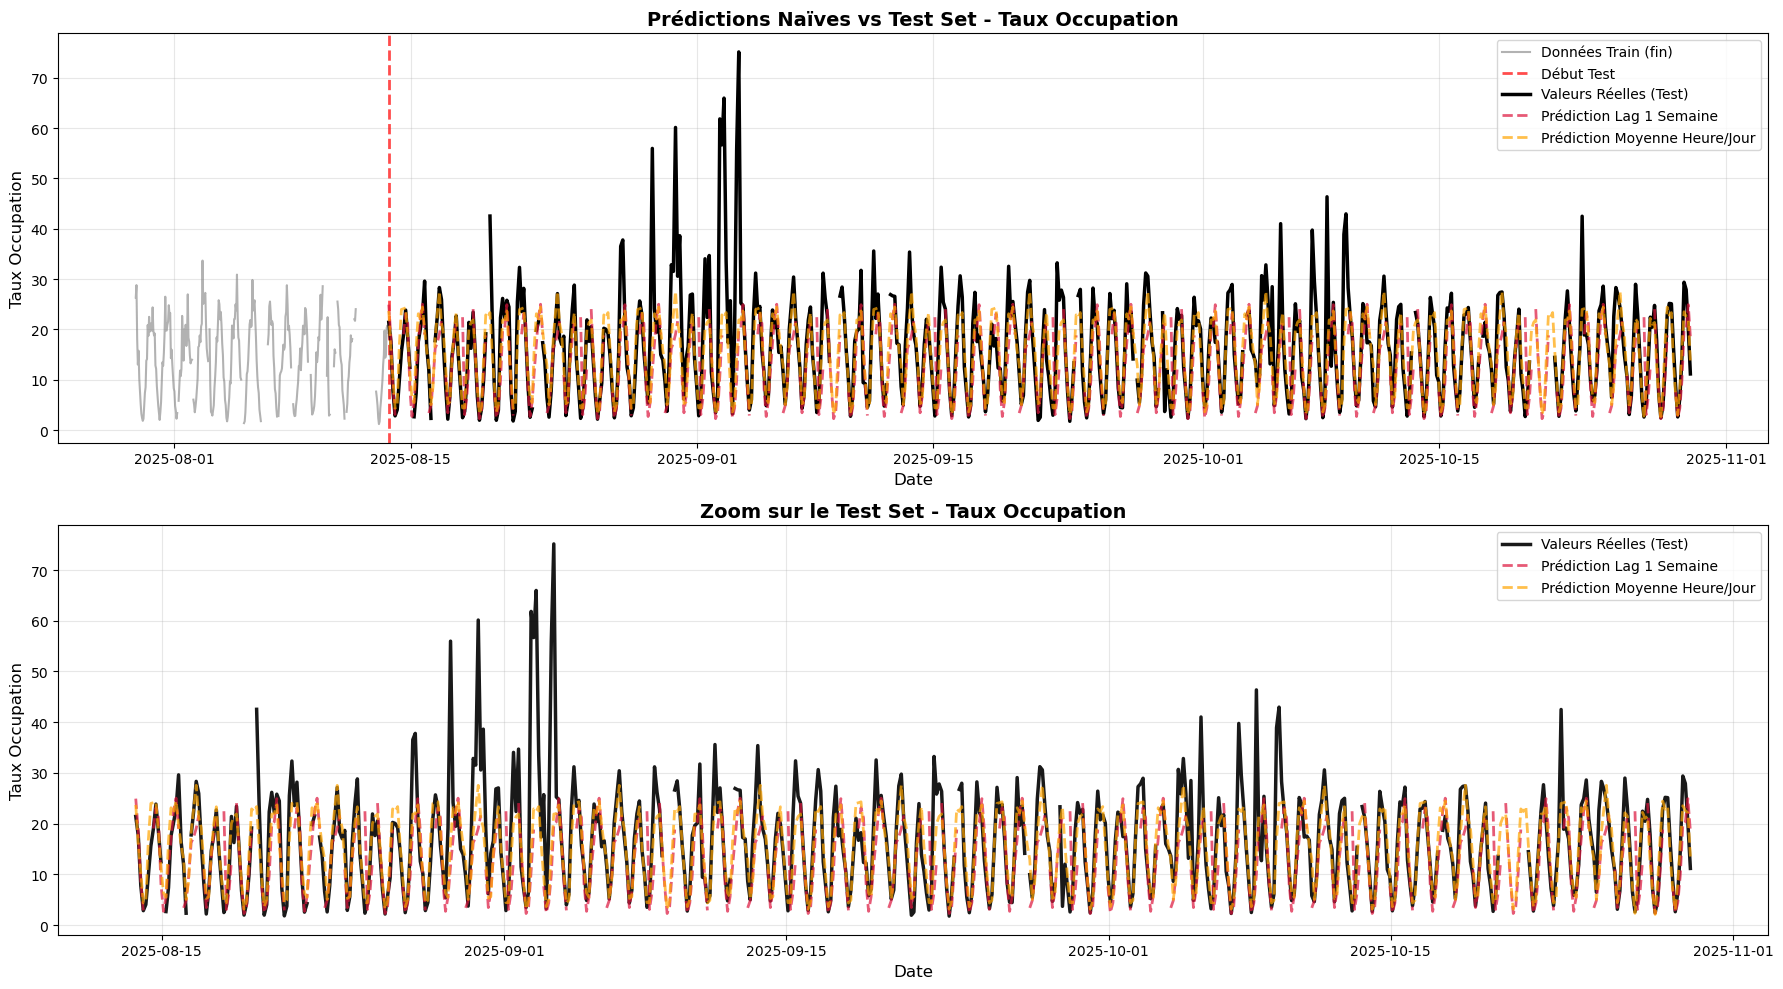

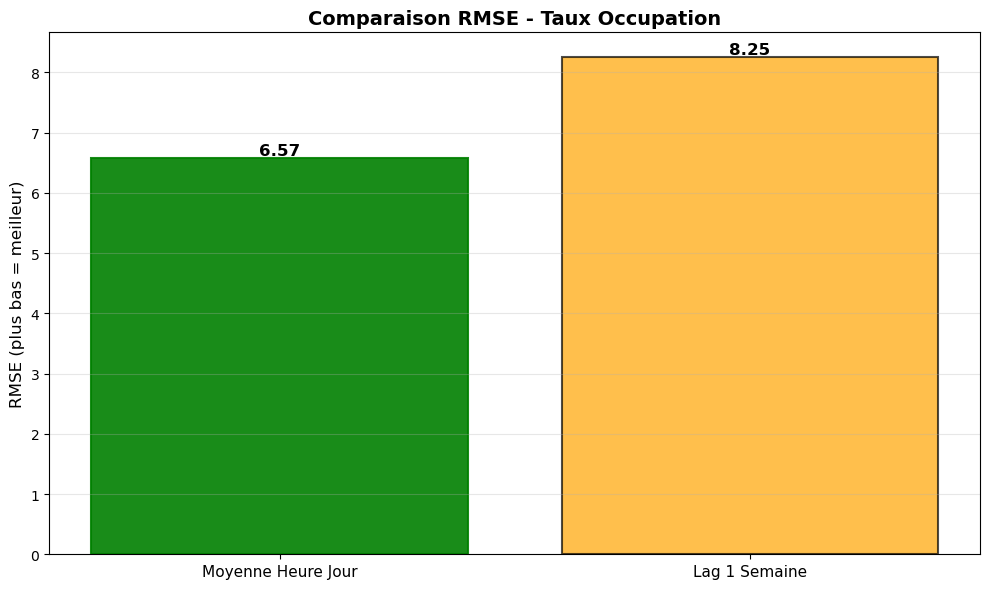


✓ ANALYSE TERMINÉE


In [4]:
# --- 1. SPLIT TEMPOREL 80/20 ---

def temporal_split(df, train_ratio=0.8):
    """
    Split temporel simple : 80% train, 20% test
    """
    n = len(df)
    train_end = int(n * train_ratio)
    
    train_set = df.iloc[:train_end].copy()
    test_set = df.iloc[train_end:].copy()
    
    print(f"\nDataset total : {n} points")
    print(f"Train : {len(train_set)} points ({train_ratio*100:.0f}%)")
    print(f"Test : {len(test_set)} points ({(1-train_ratio)*100:.0f}%)")
    
    if isinstance(df.index, pd.DatetimeIndex):
        print(f"\nPériode d'entraînement : {train_set.index[0]} à {train_set.index[-1]}")
        print(f"Période de test : {test_set.index[0]} à {test_set.index[-1]}")
    
    return train_set, test_set


# --- 2. MODÈLES NAÏFS ---

def create_naive_predictions(train_set, test_set, target_col):
    """
    Crée les prédictions naïves à partir du train set uniquement
    
    Deux stratégies :
    1. Lag 1 semaine (168h) : répète les valeurs de la dernière semaine du train
    2. Moyenne par heure/jour : moyenne de chaque heure/jour de la semaine du train
    """
    predictions = pd.DataFrame(index=test_set.index)
    
    # Vérifier si on a un index datetime
    has_datetime = isinstance(train_set.index, pd.DatetimeIndex)
    
    # --- Stratégie 1 : LAG 168H (dernière semaine du train) ---
    last_week_train = train_set[target_col].iloc[-168:].values
    n_test = len(test_set)
    
    # Répéter le pattern de la dernière semaine
    n_repeats = int(np.ceil(n_test / 168))
    lag_168_pred = np.tile(last_week_train, n_repeats)[:n_test]
    predictions[f'{target_col}_pred_lag_1_semaine'] = lag_168_pred
    
    # --- Stratégie 2 : MOYENNE PAR HEURE ET JOUR DE LA SEMAINE ---
    if has_datetime:
        # Calculer les moyennes par heure et jour de la semaine sur le train
        train_hourly_weekly = train_set.groupby([
            train_set.index.hour,
            train_set.index.dayofweek
        ])[target_col].mean()
        
        # Appliquer ces moyennes au test set
        seasonal_pred = []
        for idx in test_set.index:
            key = (idx.hour, idx.dayofweek)
            if key in train_hourly_weekly.index:
                seasonal_pred.append(train_hourly_weekly[key])
            else:
                # Si pas de données pour cette combinaison, utiliser la moyenne globale
                seasonal_pred.append(train_set[target_col].mean())
        
        predictions[f'{target_col}_pred_moyenne_heure_jour'] = seasonal_pred
    else:
        print(f"⚠️ Pas d'index datetime : la stratégie 'Moyenne par heure/jour' ne peut pas être créée")
    
    return predictions


# --- 3. ÉVALUATION RMSE ---

def calculate_rmse(test_set, target_col, predictions_df):
    """
    Calcule le RMSE pour chaque modèle
    """
    results = []
    
    for pred_col in predictions_df.columns:
        y_true = test_set[target_col].values
        y_pred = predictions_df[pred_col].values
        
        # Supprimer les NaN
        mask = ~(np.isnan(y_true) | np.isnan(y_pred))
        y_true_clean = y_true[mask]
        y_pred_clean = y_pred[mask]
        
        if len(y_true_clean) > 0:
            rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
            model_name = pred_col.replace(f'{target_col}_pred_', '').replace('_', ' ').title()
            
            results.append({
                'Modèle': model_name,
                'RMSE': rmse,
                'N échantillons': len(y_true_clean)
            })
    
    if not results:
        return pd.DataFrame()
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('RMSE')
    
    return results_df


# --- 4. VISUALISATION ---

def plot_predictions_comparison(train_set, test_set, target_col, predictions_df, max_points=500):
    """
    Visualise les prédictions naïves vs test set
    """
    # Limiter le nombre de points pour la lisibilité
    if len(test_set) > max_points:
        step = len(test_set) // max_points
        test_plot = test_set.iloc[::step]
        pred_plot = predictions_df.iloc[::step]
    else:
        test_plot = test_set
        pred_plot = predictions_df
    
    fig, axes = plt.subplots(2, 1, figsize=(18, 10))
    
    x_axis = test_plot.index if isinstance(test_plot.index, pd.DatetimeIndex) else range(len(test_plot))
    
    # --- Graphique 1 : Vue complète avec train et test ---
    # Afficher les dernières 336h du train (2 semaines)
    train_plot = train_set.iloc[-336:] if len(train_set) > 336 else train_set
    train_x = train_plot.index if isinstance(train_plot.index, pd.DatetimeIndex) else range(len(train_plot))
    
    axes[0].plot(train_x, train_plot[target_col], 
                 label='Données Train (fin)', color='gray', linewidth=1.5, alpha=0.6)
    axes[0].axvline(x=test_plot.index[0] if isinstance(test_plot.index, pd.DatetimeIndex) else 0,
                    color='red', linestyle='--', linewidth=2, label='Début Test', alpha=0.7)
    axes[0].plot(x_axis, test_plot[target_col], 
                 label='Valeurs Réelles (Test)', color='black', linewidth=2.5)
    
    # Ajouter les prédictions
    colors = ['crimson', 'orange']
    labels_map = {
        'lag_1_semaine': 'Prédiction Lag 1 Semaine',
        'moyenne_heure_jour': 'Prédiction Moyenne Heure/Jour'
    }
    
    for i, pred_col in enumerate(pred_plot.columns):
        model_key = pred_col.replace(f'{target_col}_pred_', '')
        label = labels_map.get(model_key, model_key)
        axes[0].plot(x_axis, pred_plot[pred_col],
                    label=label,
                    color=colors[i % len(colors)], 
                    linestyle='--', alpha=0.7, linewidth=2)
    
    axes[0].set_title(f"Prédictions Naïves vs Test Set - {target_col.replace('_', ' ').title()}", 
                     fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Date" if isinstance(test_plot.index, pd.DatetimeIndex) else "Index", fontsize=12)
    axes[0].set_ylabel(target_col.replace('_', ' ').title(), fontsize=12)
    axes[0].legend(loc='best', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # --- Graphique 2 : Zoom sur le test set uniquement ---
    axes[1].plot(x_axis, test_plot[target_col], 
                 label='Valeurs Réelles (Test)', color='black', linewidth=2.5, alpha=0.9)
    
    for i, pred_col in enumerate(pred_plot.columns):
        model_key = pred_col.replace(f'{target_col}_pred_', '')
        label = labels_map.get(model_key, model_key)
        axes[1].plot(x_axis, pred_plot[pred_col],
                    label=label,
                    color=colors[i % len(colors)], 
                    linestyle='--', alpha=0.7, linewidth=2)
    
    axes[1].set_title(f"Zoom sur le Test Set - {target_col.replace('_', ' ').title()}", 
                     fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Date" if isinstance(test_plot.index, pd.DatetimeIndex) else "Index", fontsize=12)
    axes[1].set_ylabel(target_col.replace('_', ' ').title(), fontsize=12)
    axes[1].legend(loc='best', fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_rmse_comparison(results_df, target_col):
    """
    Graphique en barres comparant les RMSE
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    models = results_df['Modèle'].values
    rmses = results_df['RMSE'].values
    x = np.arange(len(models))
    
    bars = ax.bar(x, rmses, color=['crimson', 'orange'], alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Ajouter les valeurs au-dessus des barres
    for i, (bar, rmse) in enumerate(zip(bars, rmses)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{rmse:.2f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_title(f'Comparaison RMSE - {target_col.replace("_", " ").title()}', 
                fontsize=14, fontweight='bold')
    ax.set_ylabel('RMSE (plus bas = meilleur)', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Mettre en évidence le meilleur modèle
    best_idx = np.argmin(rmses)
    bars[best_idx].set_color('green')
    bars[best_idx].set_alpha(0.9)
    
    plt.tight_layout()
    plt.show()


# --- UTILISATION PRINCIPALE ---

# Identifier et préparer l'index datetime si nécessaire
date_column = None
for col in df_final.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        print(f"Colonne datetime détectée : {col}")
        date_column = col
        df_final[col] = pd.to_datetime(df_final[col])
        df_final = df_final.set_index(col)
        break

# Colonnes cibles
target_columns = ['debit_horaire', 'taux_occupation']

# S'assurer que les données sont triées par date
if isinstance(df_final.index, pd.DatetimeIndex):
    df_final = df_final.sort_index()

print(f"\n{'='*80}")
print("MODÈLES NAÏFS - PRÉDICTION AVEC SPLIT 80/20")
print(f"{'='*80}")

# 1. Split temporel (80% train, 20% test)
train_set, test_set = temporal_split(df_final, train_ratio=0.8)

# 2. Pour chaque variable cible
for target_col in target_columns:
    print(f"\n{'='*80}")
    print(f"ANALYSE POUR : {target_col.upper()}")
    print(f"{'='*80}")
    
    # Vérifier que la colonne existe
    if target_col not in train_set.columns:
        print(f"❌ Colonne {target_col} non trouvée dans le dataset")
        continue
    
    # Créer les prédictions naïves
    print("\n📊 Création des prédictions naïves...")
    predictions = create_naive_predictions(train_set, test_set, target_col)
    
    print(f"✓ Modèles créés : {len(predictions.columns)}")
    for col in predictions.columns:
        model_name = col.replace(f'{target_col}_pred_', '').replace('_', ' ').title()
        print(f"  - {model_name}")
    
    # Calculer les RMSE
    results = calculate_rmse(test_set, target_col, predictions)
    
    if not results.empty:
        print("\n" + "="*50)
        print("RÉSULTATS - RMSE")
        print("="*50)
        print(results.to_string(index=False))
        
        # Identifier le meilleur modèle
        best_model = results.iloc[0]['Modèle']
        best_rmse = results.iloc[0]['RMSE']
        print(f"\n🏆 MEILLEUR MODÈLE : {best_model}")
        print(f"   RMSE : {best_rmse:.2f}")
        
        # Visualisations
        print("\n📈 Génération des graphiques...")
        plot_predictions_comparison(train_set, test_set, target_col, predictions)
        plot_rmse_comparison(results, target_col)
    else:
        print("❌ Aucun résultat disponible pour l'évaluation")

print(f"\n{'='*80}")
print("✓ ANALYSE TERMINÉE")
print(f"{'='*80}")

## Modèle RIDGE ##

In [88]:
print(df_final.columns)

Index(['datetime', 'Identifiant arc', 'Libelle', 'debit_horaire',
       'taux_occupation', 'Etat trafic', 'Identifiant noeud amont',
       'noeud_amont', 'Identifiant noeud aval', 'noeud_aval', 'Etat arc',
       'Date debut dispo data', 'Date fin dispo data', 'geo_point_2d',
       'geo_shape', 'date', 'jour_nom', 'jour_Dimanche', 'jour_Jeudi',
       'jour_Lundi', 'jour_Mardi', 'jour_Mercredi', 'jour_Samedi',
       'jour_Vendredi', 'jour_ferie', 'veille_jour_ferie',
       'vacances_scolaires', 'precipitation_mm', 'vent_vitesse_ms',
       'temperature', 'neige_cm', 'ensoleillement_min', 'il_pleut',
       'il_fait_jour', 'debit_horaire_moyenne_3h',
       'taux_occupation_moyenne_3h', 'debit_horaire_moyenne_3j_meme_heure',
       'taux_occupation_moyenne_3j_meme_heure',
       'debit_horaire_moyenne_3s_meme_jour_heure',
       'taux_occupation_moyenne_3s_meme_jour_heure'],
      dtype='object')


In [6]:
# Convertit la colonne 'datetime' (qui est au format '2024090103') en un vrai objet datetime
# C'est la ligne de code que vous avez utilisée avec succès précédemment.
df_final['datetime'] = pd.to_datetime(df_final['datetime'], utc=True, errors='coerce')

# Crée une nouvelle colonne 'hour' en extrayant l'heure de l'index
df_final['hour'] = df_final['datetime'].dt.hour

# Vérifier le résultat
print(df_final[['hour']].head())

   hour
0     3
1     4
2     5
3     6
4     7


In [7]:
df_final.set_index('datetime', inplace=True)

In [98]:
# Définir les cibles
targets = ['debit_horaire', 'taux_occupation']

# Définir les features (tout ce qui n'est pas une cible ou une variable intermédiaire inutile)
# Assurez-vous d'exclure les colonnes non numériques comme 'jour_nom' si elles existent encore
features = ['jour_Dimanche', 'jour_Jeudi',
       'jour_Lundi', 'jour_Mardi', 'jour_Mercredi', 'jour_Samedi',
       'jour_Vendredi', 'jour_ferie', 'veille_jour_ferie',
       'vacances_scolaires', 'precipitation_mm', 'vent_vitesse_ms',
       'temperature', 'neige_cm', 'ensoleillement_min', 'il_pleut',
       'il_fait_jour','hour', 'debit_horaire_moyenne_3h',
      'taux_occupation_moyenne_3h', 'debit_horaire_moyenne_3j_meme_heure',
     'taux_occupation_moyenne_3j_meme_heure',
    'debit_horaire_moyenne_3s_meme_jour_heure',
      'taux_occupation_moyenne_3s_meme_jour_heure']

# Variales dépendant du set de test : , 'debit_horaire_moyenne_3h',
#      'taux_occupation_moyenne_3h', 'debit_horaire_moyenne_3j_meme_heure',
#     'taux_occupation_moyenne_3j_meme_heure',
#    'debit_horaire_moyenne_3s_meme_jour_heure',
#      'taux_occupation_moyenne_3s_meme_jour_heure'

# Créer un DataFrame propre en supprimant toutes les lignes avec des NaN
# (principalement celles du début à cause des lags)
df_clean = df_final.dropna(subset=features + targets)

X = df_clean[features]
y = df_clean[targets] # Garder les deux cibles pour l'instant

In [10]:
from sklearn.model_selection import train_test_split

# Split temporel : 80% le plus ancien pour l'entraînement, 20% le plus récent pour le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.05,
    shuffle=False
)

In [100]:
from sklearn.preprocessing import StandardScaler

# 1. Créer le scaler
scaler = StandardScaler()

# 2. L'entraîner UNIQUEMENT sur X_train
scaler.fit(X_train)

# 3. Transformer X_train et X_test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- Modèle 1 : Prédiction du Débit Horaire ---
model_debit = Ridge(alpha=1.0) # alpha=1.0 est une valeur de pénalité par défaut

# Entraîner le modèle sur les données d'entraînement scalées
model_debit.fit(X_train_scaled, y_train['debit_horaire'])

# --- Modèle 2 : Prédiction du Taux d'Occupation ---
model_taux = Ridge(alpha=1.0)

# Entraîner le modèle
model_taux.fit(X_train_scaled, y_train['taux_occupation'])

NameError: name 'X_train_scaled' is not defined

In [102]:
# --- Évaluation du Débit Horaire ---
pred_debit = model_debit.predict(X_test_scaled)
rmse_debit_ridge = root_mean_squared_error(y_test['debit_horaire'], pred_debit)

# --- Évaluation du Taux d'Occupation ---
pred_taux = model_taux.predict(X_test_scaled)
rmse_taux_ridge = root_mean_squared_error(y_test['taux_occupation'], pred_taux)

print("\n--- Performance de la Régression Ridge (sur le set de test) ---")
print(f"RMSE (Débit Horaire) : {rmse_debit_ridge:.2f}")
print(f"RMSE (Taux d'Occupation) : {rmse_taux_ridge:.2f}")


--- Performance de la Régression Ridge (sur le set de test) ---
RMSE (Débit Horaire) : 126.75
RMSE (Taux d'Occupation) : 3.78


In [103]:
print(y_test.head())

                           debit_horaire  taux_occupation
datetime                                                 
2025-10-14 16:00:00+00:00          897.0         18.81222
2025-10-14 17:00:00+00:00          956.0         20.43000
2025-10-14 18:00:00+00:00          932.0         21.01723
2025-10-14 19:00:00+00:00          920.0         19.66000
2025-10-14 20:00:00+00:00          669.0         10.92667


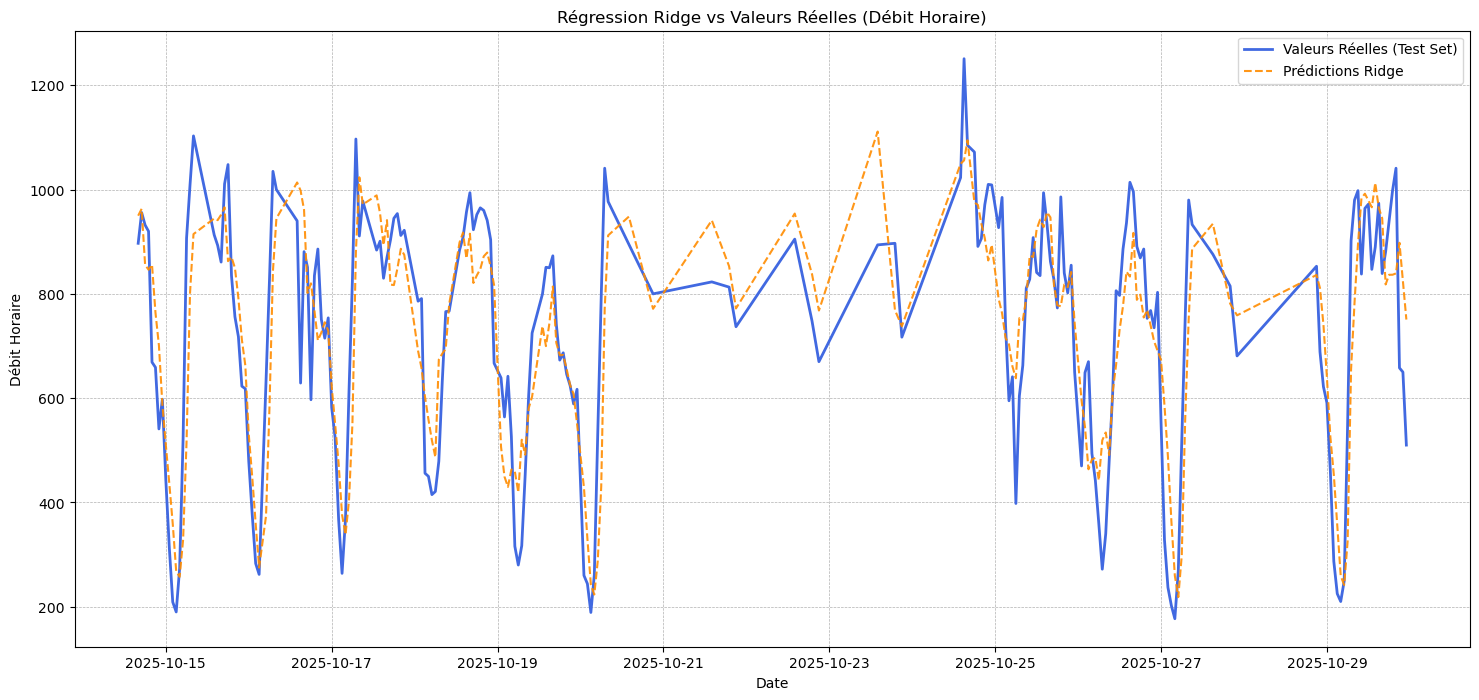

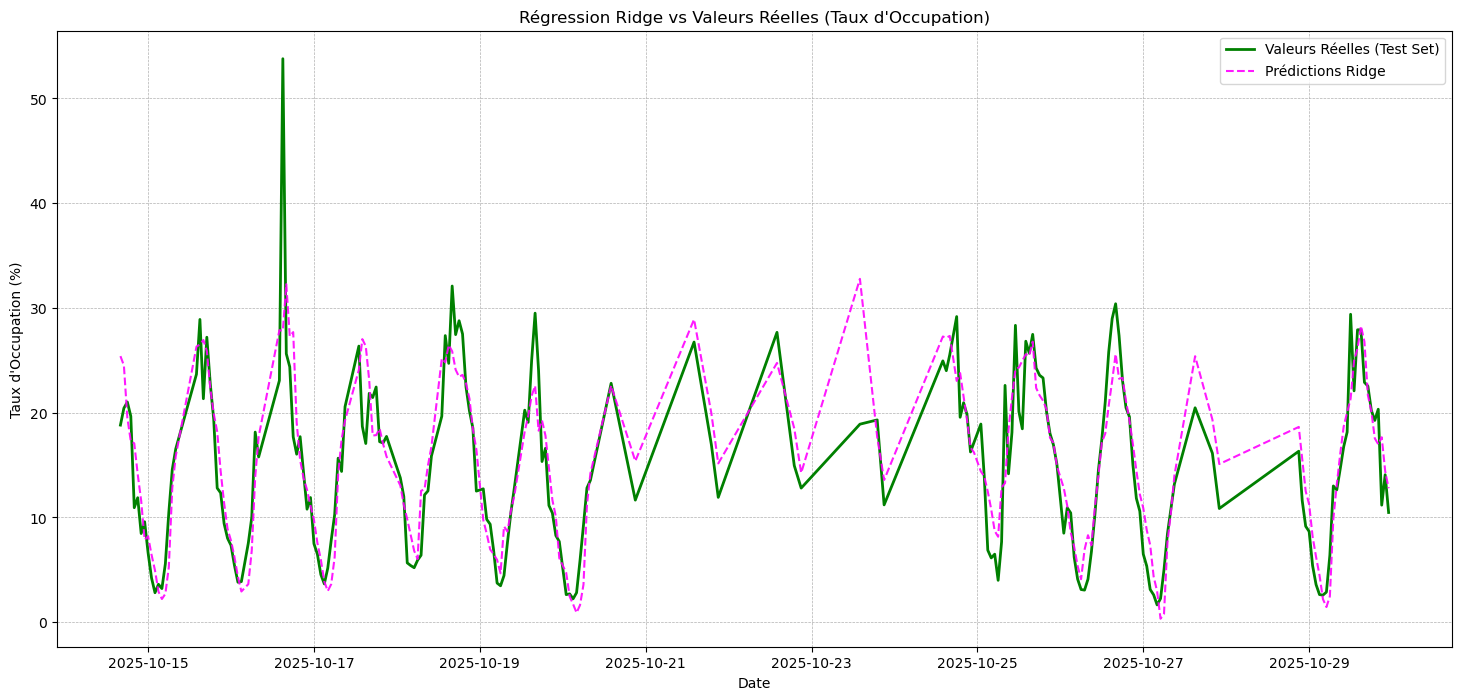

In [104]:
# --- 1. PRÉPARATION DES SÉRIES POUR LE PLOTTING ---

# Transformer le tableau de prédictions (NumPy array) en Série (Pandas Series)
# en lui associant l'index temporel du set de test.
pred_debit_series = pd.Series(pred_debit, index=y_test.index, name='Predictions_Debit')
pred_taux_series = pd.Series(pred_taux, index=y_test.index, name='Predictions_Taux')


# --- 2. VISUALISATION (pour le Débit Horaire) ---

plt.figure(figsize=(18, 8))

# Plotter les valeurs réelles (votre set de test)
plt.plot(y_test.index, y_test['debit_horaire'], label='Valeurs Réelles (Test Set)', color='royalblue', linewidth=2)

# Plotter les valeurs prédites par votre modèle Ridge
plt.plot(pred_debit_series.index, pred_debit_series, label='Prédictions Ridge', color='darkorange', linestyle='--', alpha=0.9)

plt.title("Régression Ridge vs Valeurs Réelles (Débit Horaire)")
plt.xlabel("Date")
plt.ylabel("Débit Horaire")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


# --- 3. VISUALISATION (pour le Taux d'Occupation) ---

plt.figure(figsize=(18, 8))

# Plotter les valeurs réelles
plt.plot(y_test.index, y_test['taux_occupation'], label='Valeurs Réelles (Test Set)', color='green', linewidth=2)

# Plotter les valeurs prédites
plt.plot(pred_taux_series.index, pred_taux_series, label='Prédictions Ridge', color='magenta', linestyle='--', alpha=0.9)

plt.title("Régression Ridge vs Valeurs Réelles (Taux d'Occupation)")
plt.xlabel("Date")
plt.ylabel("Taux d'Occupation (%)")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## XGBoost

In [28]:
import xgboost as xgb

# --- 1. PRÉPARATION FINALE DES DONNÉES (X et y) ---

# Définir les cibles
targets = ['debit_horaire', 'taux_occupation']

# Définir les features (TOUTES vos features)
# ASSUREZ-VOUS d'inclure les features de lag/moyennes glissantes !
features_statiques = [
    'jour_Dimanche', 'jour_Jeudi', 'jour_Lundi', 'jour_Mardi', 'jour_Mercredi', 
    'jour_Samedi', 'jour_Vendredi', 'jour_ferie', 'veille_jour_ferie',
    'vacances_scolaires', 'precipitation_mm', 'vent_vitesse_ms',
    'temperature', 'neige_cm', 'ensoleillement_min', 'il_pleut',
    'il_fait_jour', 'hour'
]

features_lags = [
    'debit_horaire_moyenne_3h', 'taux_occupation_moyenne_3h',
    'debit_horaire_moyenne_3j_meme_heure', 'taux_occupation_moyenne_3j_meme_heure',
    'debit_horaire_moyenne_3s_meme_jour_heure', 'taux_occupation_moyenne_3s_meme_jour_heure'
]

# Votre liste de features finale
features = features_statiques + features_lags

# Créer un DataFrame propre en supprimant toutes les lignes avec des NaN
df_clean = df_final.dropna(subset=features + targets)

X = df_clean[features]
y = df_clean[targets]

In [29]:
# --- 2. SÉPARATION TEMPORELLE STRICTE (Train/Test Split) ---

# Split temporel : 80% le plus ancien pour l'entraînement, 20% le plus récent pour le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    shuffle=False  # Crucial pour les séries temporelles
)

print(f"Taille X_train : {len(X_train)}, Taille X_test : {len(X_test)}")

Taille X_train : 3504, Taille X_test : 877


In [31]:
# --- 3. ENTRAÎNEMENT DU MODÈLE XGBOOST (Pas besoin de Scaler) ---

# --- Modèle 1 : Prédiction du Débit Horaire ---
print("\nEntraînement du modèle pour le Débit Horaire...")

# Instancier le modèle. 
# n_estimators=100 : va construire 100 arbres (rapide et simple pour commencer)
# random_state=42 : pour que vos résultats soient reproductibles
model_debit_xgb = xgb.XGBRegressor(n_estimators=1000, random_state=42, enable_categorical=True)

# Entraîner le modèle
model_debit_xgb.fit(X_train, y_train['debit_horaire'])

# --- Modèle 2 : Prédiction du Taux d'Occupation ---
print("Entraînement du modèle pour le Taux d'Occupation...")
model_taux_xgb = xgb.XGBRegressor(n_estimators=100, random_state=42, enable_categorical=True)

# Entraîner le modèle
model_taux_xgb.fit(X_train, y_train['taux_occupation'])

print("Entraînement terminé.")


Entraînement du modèle pour le Débit Horaire...
Entraînement du modèle pour le Taux d'Occupation...
Entraînement terminé.


In [32]:
# --- 4. ÉVALUATION DE LA PERFORMANCE ---

# --- Évaluation du Débit Horaire ---
pred_debit = model_debit_xgb.predict(X_test)
rmse_debit_xgb = root_mean_squared_error(y_test['debit_horaire'], pred_debit)

# --- Évaluation du Taux d'Occupation ---
pred_taux = model_taux_xgb.predict(X_test)
rmse_taux_xgb = root_mean_squared_error(y_test['taux_occupation'], pred_taux)

print("\n--- Performance de XGBoost (sur le set de test) ---")
print(f"RMSE (Débit Horaire) : {rmse_debit_xgb:.2f}  (Comparez à votre Ridge et Naïf)")
print(f"RMSE (Taux d'Occupation) : {rmse_taux_xgb:.2f}  (Comparez à votre Ridge et Naïf)")


--- Performance de XGBoost (sur le set de test) ---
RMSE (Débit Horaire) : 102.26  (Comparez à votre Ridge et Naïf)
RMSE (Taux d'Occupation) : 5.92  (Comparez à votre Ridge et Naïf)



--- Importance des features (Débit Horaire) ---


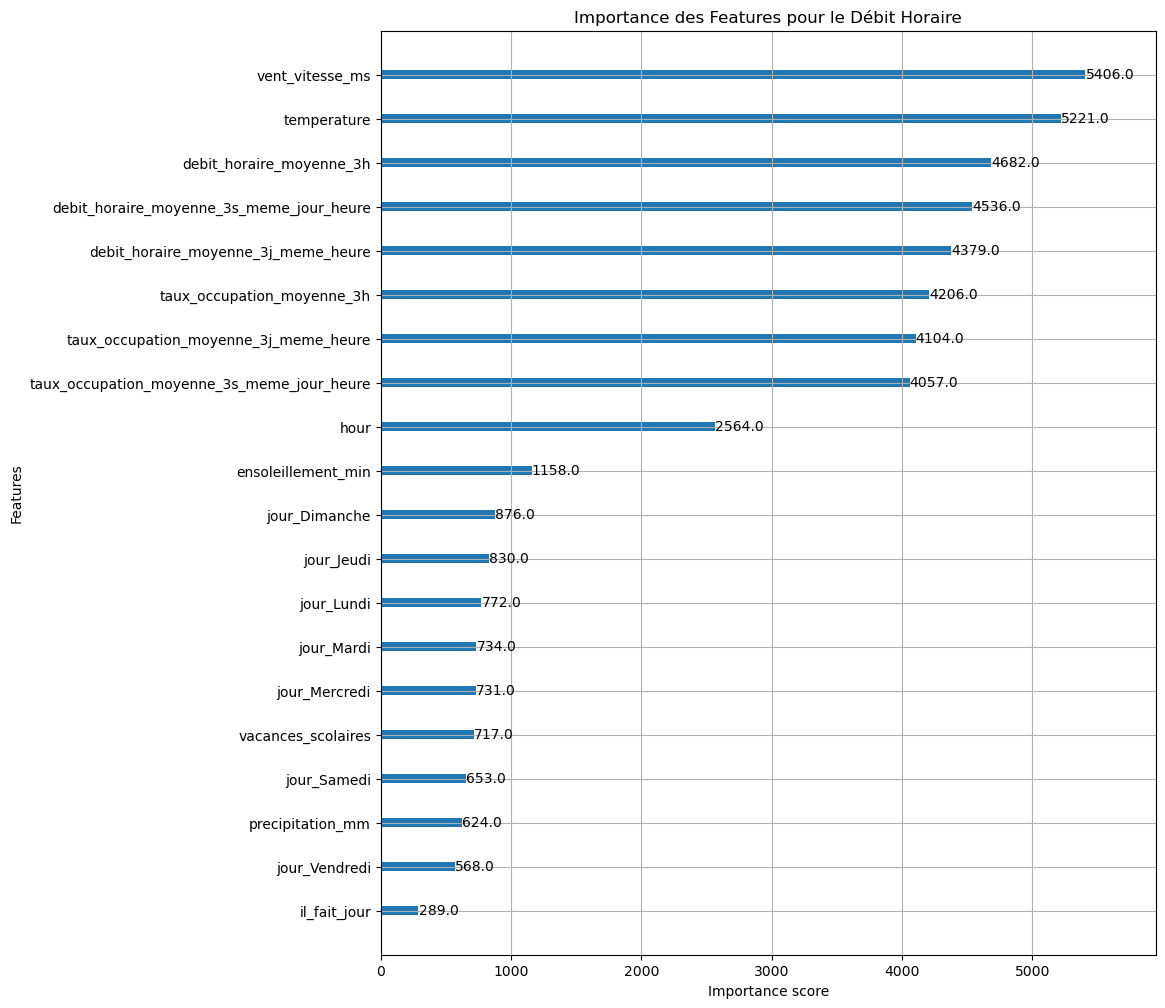

In [33]:
# --- 5. BONUS : REGARDER LES FEATURES LES PLUS IMPORTANTES ---
# C'est un énorme avantage de XGBoost pour votre présentation finale !

print("\n--- Importance des features (Débit Horaire) ---")
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(model_debit_xgb, ax=ax, max_num_features=20) # Affiche les 20 plus importantes
plt.title("Importance des Features pour le Débit Horaire")
plt.show()

## LSTM

In [34]:
# Imports pour le Modèle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error

In [57]:
# --- 1. DÉFINIR LES PARAMÈTRES ---

# C'est l'hyperparamètre le plus important : combien d'heures 
# le LSTM va-t-il "regarder en arrière" pour faire une prédiction ?
LOOKBACK = 24  # On regarde les 24 heures (1 jour) précédentes

TARGET_COL = 'debit_horaire'  # La cible que nous prédisons

# Toutes les features que le modèle regardera à chaque pas de temps
# On inclut la cible elle-même, car son historique est une feature !
FEATURES = [
    'debit_horaire', 'taux_occupation',  # Inclure les cibles comme features
    'jour_Dimanche', 'jour_Jeudi', 'jour_Lundi', 'jour_Mardi', 'jour_Mercredi', 
    'jour_Samedi', 'jour_Vendredi', 'jour_ferie', 'veille_jour_ferie',
    'vacances_scolaires', 'precipitation_mm', 'vent_vitesse_ms',
    'temperature', 'neige_cm', 'ensoleillement_min', 'il_pleut',
    'il_fait_jour', 'hour'
    # NOTE : Nous N'AVONS PAS BESOIN des features de lag manuelles (moyenne_3h, etc.)
    # Le LSTM est censé les apprendre tout seul !
]

In [58]:
# --- 2. PRÉPARATION DES DONNÉES (Étape la plus difficile) ---

# 1. Nettoyer les NaN (ceux au début du df à cause de la météo, etc.)
df_clean = df_final.dropna(subset=FEATURES)
df_data = df_clean[FEATURES] # Garder uniquement les colonnes utiles

# 2. Mise à l'échelle (Scaling) - OBLIGATOIRE pour les réseaux de neurones
# Nous utilisons MinMaxScaler (tout entre 0 et 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_data)

# 3. Création des séquences (le "film")
# C'est la fonction qui transforme le tableau 2D en "films" 3D
def create_sequences(data, lookback, features, target_col_name):
    X_seq, y_seq = [], []
    
    # Trouver l'index de notre colonne cible
    target_col_index = features.index(target_col_name)
    
    for i in range(len(data) - lookback):
        # Le "film" (X) : prend 'lookback' heures et toutes les features
        sequence_X = data[i:(i + lookback), :]
        X_seq.append(sequence_X)
        
        # La "cible" (y) : prend la valeur de la *cible* à l'heure suivante
        target_y = data[i + lookback, target_col_index]
        y_seq.append(target_y)
        
    return np.array(X_seq), np.array(y_seq)

# Créer les séquences
X_sequences, y_sequences = create_sequences(scaled_data, LOOKBACK, FEATURES, TARGET_COL)

print(f"Forme des séquences X (échantillons, pas de temps, features) : {X_sequences.shape}")
print(f"Forme des cibles y (échantillons,) : {y_sequences.shape}")


Forme des séquences X (échantillons, pas de temps, features) : (6629, 24, 20)
Forme des cibles y (échantillons,) : (6629,)


In [59]:
# --- 3. SÉPARATION TEMPORELLE (Train/Test Split) ---

# Très important : le split se fait sur les séquences, SANS mélanger (shuffle=False)
split_point = int(len(X_sequences) * 0.8)

X_train_seq, X_test_seq = X_sequences[:split_point], X_sequences[split_point:]
y_train_seq, y_test_seq = y_sequences[:split_point], y_sequences[split_point:]

# Garder l'index temporel pour le plot final
test_index = df_data.index[split_point + LOOKBACK:]

In [60]:
# --- 4. CONSTRUCTION DU MODÈLE LSTM SIMPLE ---

# Récupérer le nombre de features de nos données
n_features = X_train_seq.shape[2] 

model_lstm = Sequential()
# Couche LSTM simple avec 50 neurones de "mémoire"
model_lstm.add(LSTM(
    50, 
    activation='relu', 
    input_shape=(LOOKBACK, n_features)  # (24 heures, 20 features)
))
# Couche de sortie : 1 neurone pour prédire la valeur
model_lstm.add(Dense(1))

# Compilation du modèle
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50)             │        14,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,251 (55.67 KB)

 Trainable params: 14,251 (55.67 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# --- 5. ENTRAÎNEMENT DU MODÈLE ---
print("\nEntraînement du modèle LSTM...")

# epochs=20 : 20 passes sur les données. Augmentez si besoin mais gardez bas pour un test.
# batch_size=32 : traite les données par lots de 32 "films".
history = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1,
    shuffle=False # Important pour les séries temporelles
)

print("Entraînement terminé.")



Entraînement du modèle LSTM...
Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0202 - val_loss: 0.0104
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0103 - val_loss: 0.0075
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0085 - val_loss: 0.0058
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0072 - val_loss: 0.0047
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0060 - val_loss: 0.0039
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0052 - val_loss: 0.0035
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0046 - val_loss: 0.0032
Epoch 8/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0042 - val_loss: 0.0030
Epoch 9/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0038 - val_loss: 0.0029
Epoch 10/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0036 - val_loss: 0.0029
Epoch 11/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0033 - val_loss: 0.0028
Epoch 12/20

In [62]:
# --- 6. PRÉDICTION ET "DÉ-SCALING" ---

# 1. Prédire sur le set de test
y_pred_scaled = model_lstm.predict(X_test_seq)

# 2. "Dé-scaler" les prédictions (INVERSION)
# C'est l'étape la plus délicate. Le scaler a été entraîné sur TOUTES les features.
# Nous devons "tromper" le scaler pour qu'il n'inverse que notre colonne cible.

# Créer un tableau rempli de zéros avec la bonne forme (nb_lignes, nb_features)
dummy_array = np.zeros((len(y_pred_scaled), n_features))
# Placer nos prédictions (scaled) dans la première colonne (celle du débit)
dummy_array[:, 0] = y_pred_scaled.ravel() 
# Inverser la transformation de ce tableau
y_pred_unscaled = scaler.inverse_transform(dummy_array)[:, 0]

# 3. "Dé-scaler" les vraies valeurs du test set pour la comparaison
dummy_array_true = np.zeros((len(y_test_seq), n_features))
dummy_array_true[:, 0] = y_test_seq.ravel()
y_test_unscaled = scaler.inverse_transform(dummy_array_true)[:, 0]

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step



--- Performance du Modèle LSTM (sur le set de test) ---
RMSE (Débit Horaire) : 117.75 (Comparez à XGBoost/Ridge)


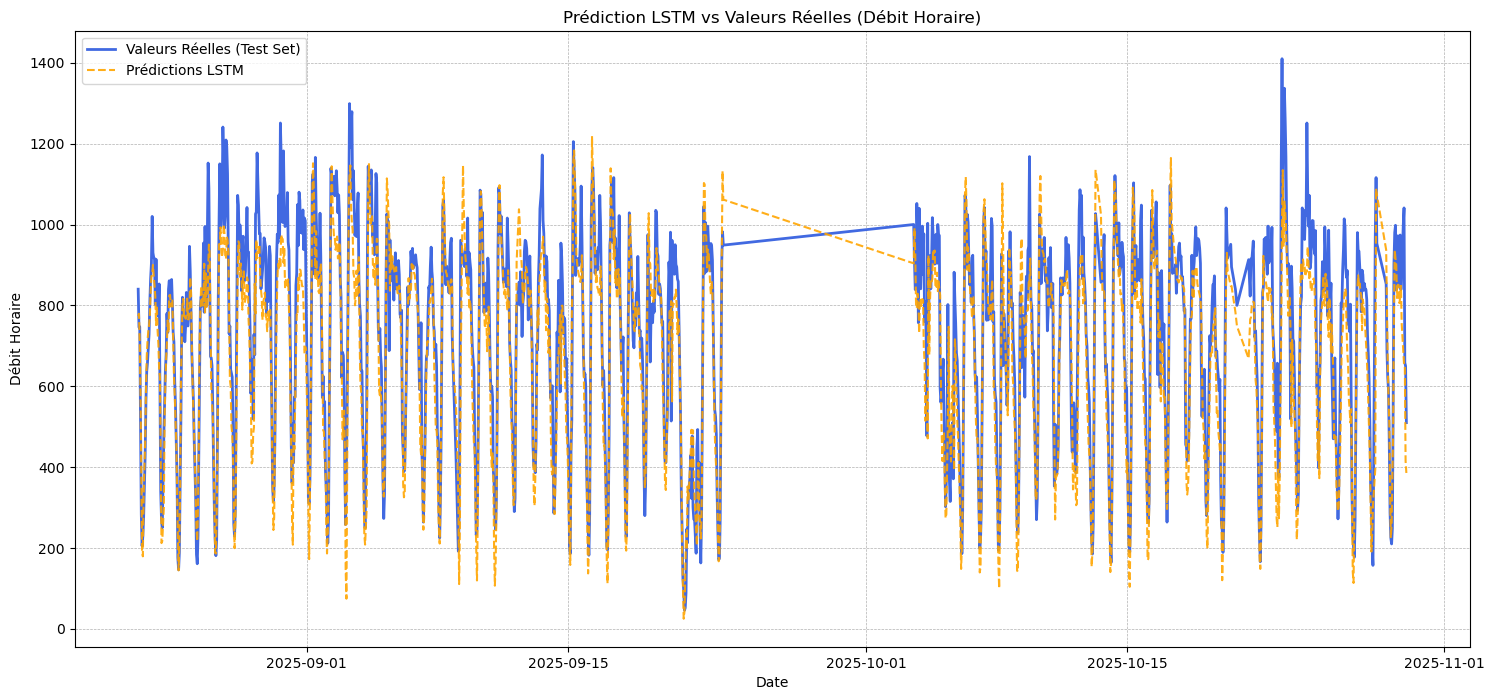

In [63]:
# --- 7. ÉVALUATION ET VISUALISATION ---

# Calculer le RMSE sur les données réelles (non scalées)
rmse_lstm = root_mean_squared_error(y_test_unscaled, y_pred_unscaled)
print(f"\n--- Performance du Modèle LSTM (sur le set de test) ---")
print(f"RMSE (Débit Horaire) : {rmse_lstm:.2f} (Comparez à XGBoost/Ridge)")

# Visualisation
plt.figure(figsize=(18, 8))
plt.plot(test_index, y_test_unscaled, label='Valeurs Réelles (Test Set)', color='royalblue', linewidth=2)
plt.plot(test_index, y_pred_unscaled, label='Prédictions LSTM', color='orange', linestyle='--', alpha=0.9)
plt.title("Prédiction LSTM vs Valeurs Réelles (Débit Horaire)")
plt.xlabel("Date")
plt.ylabel("Débit Horaire")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

### LSTM finetuning

In [64]:
# Imports pour le Modèle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error
from itertools import product

In [65]:
# --- 1. DÉFINIR LES PARAMÈTRES ---

TARGET_COL = 'debit_horaire'

FEATURES = [
    'debit_horaire', 'taux_occupation',
    'jour_Dimanche', 'jour_Jeudi', 'jour_Lundi', 'jour_Mardi', 'jour_Mercredi', 
    'jour_Samedi', 'jour_Vendredi', 'jour_ferie', 'veille_jour_ferie',
    'vacances_scolaires', 'precipitation_mm', 'vent_vitesse_ms',
    'temperature', 'neige_cm', 'ensoleillement_min', 'il_pleut',
    'il_fait_jour', 'hour'
]

In [81]:
# --- 2. GRILLE D'HYPERPARAMÈTRES À TESTER ---

param_grid = {
    'lookback': [12, 24, 48],           # Fenêtre temporelle (heures)
    'lstm_units': [32, 50, 64],         # Nombre de neurones LSTM
    'dropout_rate': [0.0, 0.2],         # Régularisation (0 = pas de dropout)
    'batch_size': [32, 64],             # Taille des lots
    'epochs': [20]                  # Nombre d'époques
}

print("=== Configuration de la Grid Search ===")
print(f"Nombre total de combinaisons : {np.prod([len(v) for v in param_grid.values()])}")
print(f"Paramètres à tester : {param_grid}\n")

=== Configuration de la Grid Search ===
Nombre total de combinaisons : 36
Paramètres à tester : {'lookback': [12, 24, 48], 'lstm_units': [32, 50, 64], 'dropout_rate': [0.0, 0.2], 'batch_size': [32, 64], 'epochs': [20]}



In [75]:
# --- 3. PRÉPARATION DES DONNÉES ---

df_clean = df_final.dropna(subset=FEATURES)
df_data = df_clean[FEATURES]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_data)

In [76]:
# --- 4. FONCTION DE CRÉATION DE SÉQUENCES ---

def create_sequences(data, lookback, features, target_col_name):
    X_seq, y_seq = [], []
    target_col_index = features.index(target_col_name)
    
    for i in range(len(data) - lookback):
        sequence_X = data[i:(i + lookback), :]
        X_seq.append(sequence_X)
        target_y = data[i + lookback, target_col_index]
        y_seq.append(target_y)
        
    return np.array(X_seq), np.array(y_seq)

In [77]:
# --- 5. FONCTION DE VALIDATION TEMPORELLE (TIME SERIES SPLIT) ---

def time_series_split(X, y, n_splits=3):
    """
    Split temporel strict : chaque fold utilise plus de données d'entraînement
    et teste sur la période suivante (pas de mélange temporel).
    """
    n_samples = len(X)
    test_size = n_samples // (n_splits + 1)
    
    splits = []
    for i in range(n_splits):
        # Train : du début jusqu'à un certain point
        train_end = n_samples - test_size * (n_splits - i)
        # Test : la période suivante
        test_start = train_end
        test_end = test_start + test_size
        
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(test_start, test_end)
        
        splits.append((train_idx, test_idx))
    
    return splits

In [78]:
# --- 6. FONCTION DE CONSTRUCTION DU MODÈLE ---

def build_model(lookback, n_features, lstm_units, dropout_rate):
    """Construit un modèle LSTM avec les hyperparamètres donnés."""
    model = Sequential()
    model.add(LSTM(lstm_units, activation='relu', input_shape=(lookback, n_features)))
    
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model

In [79]:
# --- 7. FONCTION D'ÉVALUATION AVEC VALIDATION TEMPORELLE ---

def evaluate_params(params, scaled_data, features, target_col, n_splits=3):
    """
    Évalue un ensemble d'hyperparamètres avec validation temporelle stricte.
    Retourne le RMSE moyen sur les folds de validation.
    """
    lookback = params['lookback']
    
    # Créer les séquences
    X_seq, y_seq = create_sequences(scaled_data, lookback, features, target_col)
    n_features = X_seq.shape[2]
    
    # Validation temporelle
    splits = time_series_split(X_seq, y_seq, n_splits=n_splits)
    rmse_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        X_train, X_val = X_seq[train_idx], X_seq[val_idx]
        y_train, y_val = y_seq[train_idx], y_seq[val_idx]
        
        # Construire et entraîner le modèle
        model = build_model(
            lookback=lookback,
            n_features=n_features,
            lstm_units=params['lstm_units'],
            dropout_rate=params['dropout_rate']
        )
        
        # Entraînement silencieux (verbose=0)
        model.fit(
            X_train, y_train,
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            validation_data=(X_val, y_val),
            verbose=0,
            shuffle=False
        )
        
        # Prédiction et dé-scaling
        y_pred_scaled = model.predict(X_val, verbose=0)
        
        # Dé-scaler les prédictions
        dummy_pred = np.zeros((len(y_pred_scaled), n_features))
        dummy_pred[:, 0] = y_pred_scaled.ravel()
        y_pred_unscaled = scaler.inverse_transform(dummy_pred)[:, 0]
        
        # Dé-scaler les vraies valeurs
        dummy_true = np.zeros((len(y_val), n_features))
        dummy_true[:, 0] = y_val.ravel()
        y_val_unscaled = scaler.inverse_transform(dummy_true)[:, 0]
        
        # Calculer RMSE
        rmse = root_mean_squared_error(y_val_unscaled, y_pred_unscaled)
        rmse_scores.append(rmse)
        
        # Libérer la mémoire
        del model
        tf.keras.backend.clear_session()
    
    return np.mean(rmse_scores), np.std(rmse_scores)

In [82]:
# --- 8. GRID SEARCH ---

print("=== Début de la Grid Search ===\n")

# Générer toutes les combinaisons
keys = param_grid.keys()
values = param_grid.values()
combinations = [dict(zip(keys, v)) for v in product(*values)]

results = []

for i, params in enumerate(combinations, 1):
    print(f"[{i}/{len(combinations)}] Test : {params}")
    
    try:
        mean_rmse, std_rmse = evaluate_params(
            params, 
            scaled_data, 
            FEATURES, 
            TARGET_COL,
            n_splits=3  # 3 folds de validation temporelle
        )
        
        result = {
            **params,
            'mean_rmse': mean_rmse,
            'std_rmse': std_rmse
        }
        results.append(result)
        
        print(f"   → RMSE moyen : {mean_rmse:.2f} (±{std_rmse:.2f})\n")
        
    except Exception as e:
        print(f"   → Erreur : {e}\n")
        continue

=== Début de la Grid Search ===

[1/36] Test : {'lookback': 12, 'lstm_units': 32, 'dropout_rate': 0.0, 'batch_size': 32, 'epochs': 20}
   → RMSE moyen : 161.51 (±34.17)

[2/36] Test : {'lookback': 12, 'lstm_units': 32, 'dropout_rate': 0.0, 'batch_size': 64, 'epochs': 20}
   → RMSE moyen : 150.80 (±21.40)

[3/36] Test : {'lookback': 12, 'lstm_units': 32, 'dropout_rate': 0.2, 'batch_size': 32, 'epochs': 20}
   → RMSE moyen : 155.36 (±34.68)

[4/36] Test : {'lookback': 12, 'lstm_units': 32, 'dropout_rate': 0.2, 'batch_size': 64, 'epochs': 20}
   → RMSE moyen : 158.62 (±29.61)

[5/36] Test : {'lookback': 12, 'lstm_units': 50, 'dropout_rate': 0.0, 'batch_size': 32, 'epochs': 20}
   → RMSE moyen : 148.70 (±11.78)

[6/36] Test : {'lookback': 12, 'lstm_units': 50, 'dropout_rate': 0.0, 'batch_size': 64, 'epochs': 20}
   → RMSE moyen : 144.91 (±23.42)

[7/36] Test : {'lookback': 12, 'lstm_units': 50, 'dropout_rate': 0.2, 'batch_size': 32, 'epochs': 20}
   → RMSE moyen : 146.18 (±23.54)

[8/36] T

In [83]:
# --- 9. RÉSULTATS DE LA GRID SEARCH ---

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('mean_rmse')

print("="*80)
print("=== RÉSULTATS DE LA GRID SEARCH (TOP 5) ===")
print("="*80)
print(results_df.head(10).to_string(index=False))
print("\n")

# Meilleurs hyperparamètres
best_params = results_df.iloc[0].to_dict()
print("=== MEILLEURS HYPERPARAMÈTRES ===")
for key, value in best_params.items():
    if key not in ['mean_rmse', 'std_rmse']:
        print(f"{key:15s} : {value}")
print(f"\nRMSE de validation : {best_params['mean_rmse']:.2f} (±{best_params['std_rmse']:.2f})")

=== RÉSULTATS DE LA GRID SEARCH (TOP 5) ===
 lookback  lstm_units  dropout_rate  batch_size  epochs  mean_rmse  std_rmse
       48          64           0.2          32      20 139.883453 16.964723
       24          64           0.2          32      20 141.538109 24.265030
       24          50           0.2          32      20 141.785155 22.640932
       48          64           0.0          64      20 142.155817 23.742926
       48          32           0.0          32      20 142.472294 22.257578
       48          50           0.0          64      20 142.514752 24.872519
       24          50           0.0          32      20 144.194561 14.850608
       12          50           0.0          64      20 144.907379 23.420345
       12          64           0.0          64      20 144.934711 22.707142
       48          32           0.2          32      20 145.580415 31.889370


=== MEILLEURS HYPERPARAMÈTRES ===
lookback        : 48.0
lstm_units      : 64.0
dropout_rate    : 0.2
batch


=== ENTRAÎNEMENT FINAL SUR TRAIN/TEST ===

Entraînement du modèle final avec les meilleurs hyperparamètres...
Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0197 - val_loss: 0.0143
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0125 - val_loss: 0.0094
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0101 - val_loss: 0.0072
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0085 - val_loss: 0.0064
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0077 - val_loss: 0.0050
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0071 - val_loss: 0.0051
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0061 - val_loss: 0.0047
Epoch 8/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0059 - val_loss: 0.0044
Epoch 9/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0053 - val_loss: 0.0042
Epoch 10/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0051 - val_loss: 0.0042
Epoch 11/20
166/16

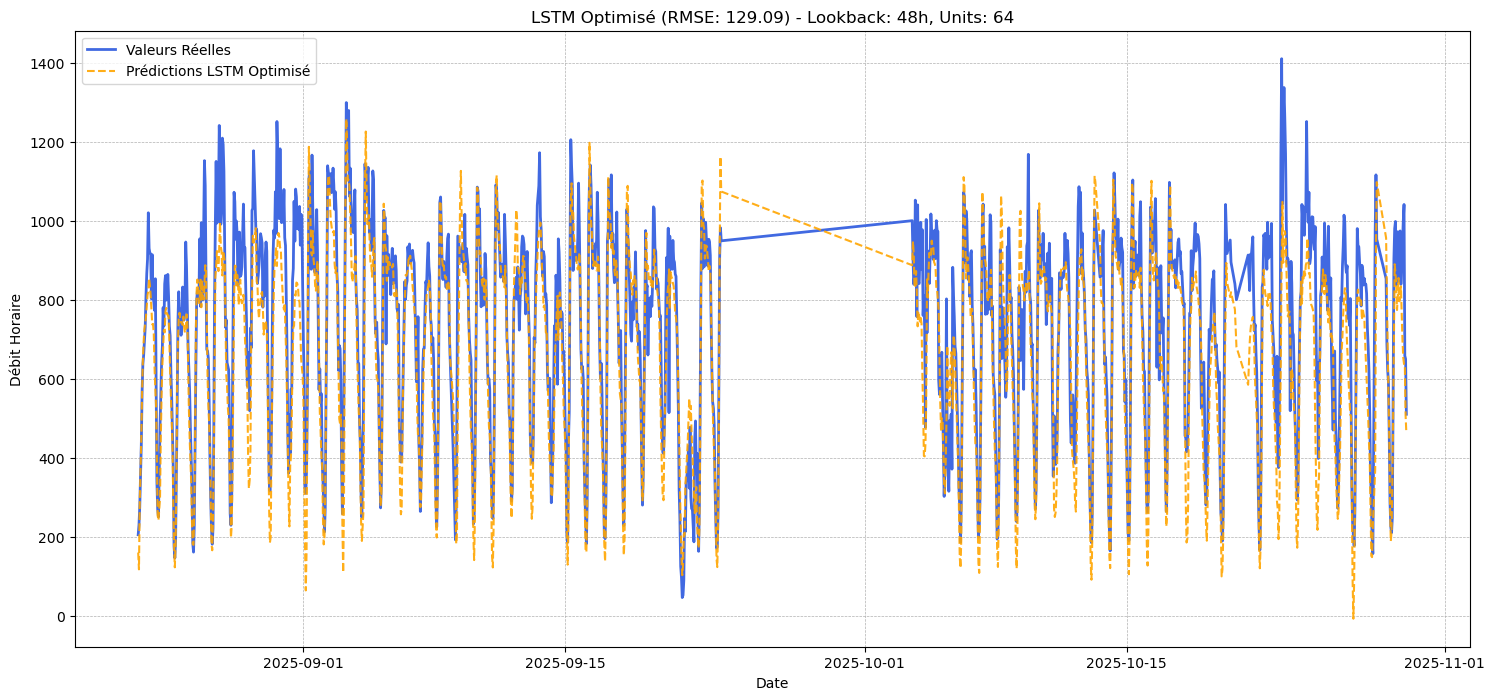


✓ Résultats sauvegardés dans 'lstm_gridsearch_results.csv'


In [84]:
# --- 10. ENTRAÎNEMENT FINAL AVEC LES MEILLEURS PARAMÈTRES ---

print("\n" + "="*80)
print("=== ENTRAÎNEMENT FINAL SUR TRAIN/TEST ===")
print("="*80)

best_lookback = int(best_params['lookback'])
best_lstm_units = int(best_params['lstm_units'])
best_dropout = float(best_params['dropout_rate'])
best_batch_size = int(best_params['batch_size'])
best_epochs = int(best_params['epochs'])

# Créer les séquences avec le meilleur lookback
X_sequences, y_sequences = create_sequences(scaled_data, best_lookback, FEATURES, TARGET_COL)
n_features = X_sequences.shape[2]

# Split temporel 80/20
split_point = int(len(X_sequences) * 0.8)
X_train_seq, X_test_seq = X_sequences[:split_point], X_sequences[split_point:]
y_train_seq, y_test_seq = y_sequences[:split_point], y_sequences[split_point:]

test_index = df_data.index[split_point + best_lookback:]

# Construire le modèle final
final_model = build_model(best_lookback, n_features, best_lstm_units, best_dropout)

print(f"\nEntraînement du modèle final avec les meilleurs hyperparamètres...")
history = final_model.fit(
    X_train_seq, y_train_seq,
    epochs=best_epochs,
    batch_size=best_batch_size,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1,
    shuffle=False
)

# Prédiction finale
y_pred_scaled = final_model.predict(X_test_seq)

# Dé-scaling
dummy_pred = np.zeros((len(y_pred_scaled), n_features))
dummy_pred[:, 0] = y_pred_scaled.ravel()
y_pred_unscaled = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_true = np.zeros((len(y_test_seq), n_features))
dummy_true[:, 0] = y_test_seq.ravel()
y_test_unscaled = scaler.inverse_transform(dummy_true)[:, 0]

# Évaluation finale
rmse_final = root_mean_squared_error(y_test_unscaled, y_pred_unscaled)

print(f"\n" + "="*80)
print(f"RMSE FINAL (Test Set) : {rmse_final:.2f}")
print("="*80)

# Visualisation
plt.figure(figsize=(18, 8))
plt.plot(test_index, y_test_unscaled, label='Valeurs Réelles', color='royalblue', linewidth=2)
plt.plot(test_index, y_pred_unscaled, label='Prédictions LSTM Optimisé', color='orange', linestyle='--', alpha=0.9)
plt.title(f"LSTM Optimisé (RMSE: {rmse_final:.2f}) - Lookback: {best_lookback}h, Units: {best_lstm_units}")
plt.xlabel("Date")
plt.ylabel("Débit Horaire")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# Sauvegarder les résultats
results_df.to_csv('lstm_gridsearch_results.csv', index=False)
print("\n✓ Résultats sauvegardés dans 'lstm_gridsearch_results.csv'")

## Prophet (Google Colab)

In [3]:
# Prérequis : pip install prophet
from prophet import Prophet
from sklearn.metrics import root_mean_squared_error        

# --- Étape 1 : Préparer le DataFrame pour Prophet ---

# Partir de votre df_final (AVANT le scaling ou le split)
# Renommer les colonnes obligatoires
df_prophet = df_final.reset_index().rename(columns={
    'datetime': 'ds',
    'debit_horaire': 'y'
})

# Définir les noms de toutes vos autres features (météo, jours, etc.)
# Celles-ci sont vos "régresseurs externes"
regresseurs = [
    'jour_Dimanche', 'jour_Jeudi', 'jour_Lundi', 'jour_Mardi', 
    'jour_Mercredi', 'jour_Samedi', 'jour_Vendredi', 'jour_ferie', 
    'veille_jour_ferie', 'vacances_scolaires', 'precipitation_mm', 
    'vent_vitesse_ms', 'temperature', 'neige_cm', 'ensoleillement_min', 
    'il_pleut', 'il_fait_jour', 'hour'
]
# Note : On n'inclut PAS les lags ici, Prophet gère les motifs lui-même.

# --- Étape 2 : Séparation Train/Test (Temporelle) ---

split_point = int(len(df_prophet) * 0.8)
train_set = df_prophet.iloc[:split_point]
test_set = df_prophet.iloc[split_point:]

# --- Étape 3 : Entraîner le Modèle ---

# Initialiser le modèle (il détecte la saisonnalité journalière/hebdomadaire)
model_prophet = Prophet(daily_seasonality=True, weekly_seasonality=True)

# Ajouter tous vos régresseurs externes
for reg in regresseurs:
    model_prophet.add_regressor(reg)

# Entraîner le modèle
model_prophet.fit(train_set)

# --- Étape 4 : Prédire (C'est là que c'est simple) ---

# Prophet a besoin d'un DataFrame "futur" contenant les dates
# ET les valeurs futures de vos régresseurs.
# Le set de test contient déjà tout cela !
future_dataframe = test_set.drop(columns='y') # On retire la vraie valeur

# La prédiction est "récursive" par nature, mais gérée en interne
forecast = model_prophet.predict(future_dataframe)

# --- Étape 5 : Évaluation ---

# Récupérer la prédiction ('yhat') et la vraie valeur ('y')
y_pred = forecast['yhat']
y_true = test_set['y']

rmse = root_mean_squared_error(y_true, y_pred)
print(f"RMSE du modèle Prophet (Débit Horaire) : {rmse:.2f}")

# Visualiser le résultat (Prophet a ses propres outils de plot)
fig = model_prophet.plot(forecast)

AttributeError: 'Prophet' object has no attribute 'stan_backend'